# TP1 - Visión por Computadora

**Parte 1:** Algoritmo White Patch para corrección de iluminación.

**Parte 2:** Histogramas en escala de grises.

## Parte 1 - White Patch

El algoritmo **White Patch** (parche blanco) es un método sencillo de *balance de blancos* que asume que el píxel más brillante de la escena corresponde a un objeto blanco iluminado por la misma fuente de luz que el resto de la imagen.

Para cada canal de color (B, G, R en OpenCV) se busca el valor máximo y se escala el canal de modo que ese máximo pase a 255. Así se compensan las dominantes cromáticas producidas por la iluminación.

Referencia: operadores de píxel y espacios de color vistos en el material del curso (`Material/Codigo/Clase1/04.Espacios_de_color.ipynb`, `Material/Codigo/Clase2/01.Brillo.ipynb`).

In [1]:
%matplotlib inline

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def read_image_color(image_path):
    """Lee una imagen a color (BGR) con OpenCV."""
    img = cv.imread(str(image_path), cv.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")
    return img


def bgr_to_rgb(img):
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

In [3]:
def white_patch(img, percentile=100.0, show=True, title=None):
    """
    Aplica White Patch sobre una imagen BGR.

    Parameters
    ----------
    img : np.ndarray
        Imagen en formato BGR (OpenCV).
    percentile : float
        Percentil usado como referencia de blanco por canal.
        100 equivale al máximo clásico; valores menores reducen
        la sensibilidad a píxeles extremos (ruido, reflejos).
    show : bool
        Si True, muestra original vs. corregida.
    title : str, optional
        Título adicional para la figura.

    Returns
    -------
    corrected : np.ndarray
        Imagen corregida en BGR.
    factors : np.ndarray
        Factores de escala aplicados a B, G y R.
    """
    image = img.astype(np.float32)

    if percentile >= 100:
        reference = np.max(image, axis=(0, 1))
    else:
        reference = np.percentile(image, percentile, axis=(0, 1))

    reference = np.maximum(reference, 1e-6)
    factors = 255.0 / reference

    corrected = np.clip(image * factors, 0, 255).astype(np.uint8)

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(title or f"White Patch (percentil {percentile})")

        axes[0].imshow(bgr_to_rgb(img))
        axes[0].set_title(
            f"Original\nref BGR = [{reference[0]:.1f}, {reference[1]:.1f}, {reference[2]:.1f}]"
        )
        axes[0].axis("off")

        axes[1].imshow(bgr_to_rgb(corrected))
        axes[1].set_title(
            f"Corregida\nfactores BGR = [{factors[0]:.2f}, {factors[1]:.2f}, {factors[2]:.2f}]"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return corrected, factors

In [4]:
white_patch_folder = Path("white_patch")
image_paths = sorted(
    p for p in white_patch_folder.iterdir()
    if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
)

print(f"Imágenes encontradas en {white_patch_folder}/:")
for path in image_paths:
    print(f"  - {path.name}")

Imágenes encontradas en white_patch/:
  - test_blue.png
  - test_green.png
  - test_red.png
  - wp_blue.jpg
  - wp_green.png
  - wp_green2.jpg
  - wp_red.png
  - wp_red2.jpg


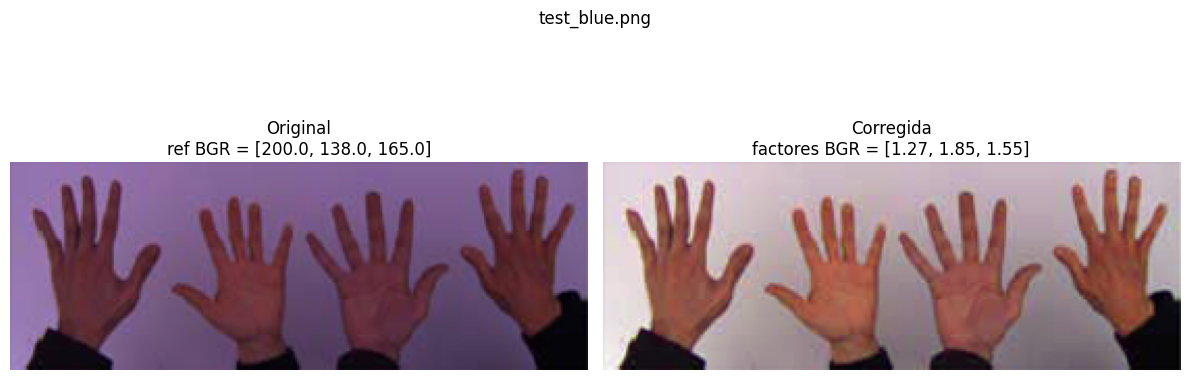

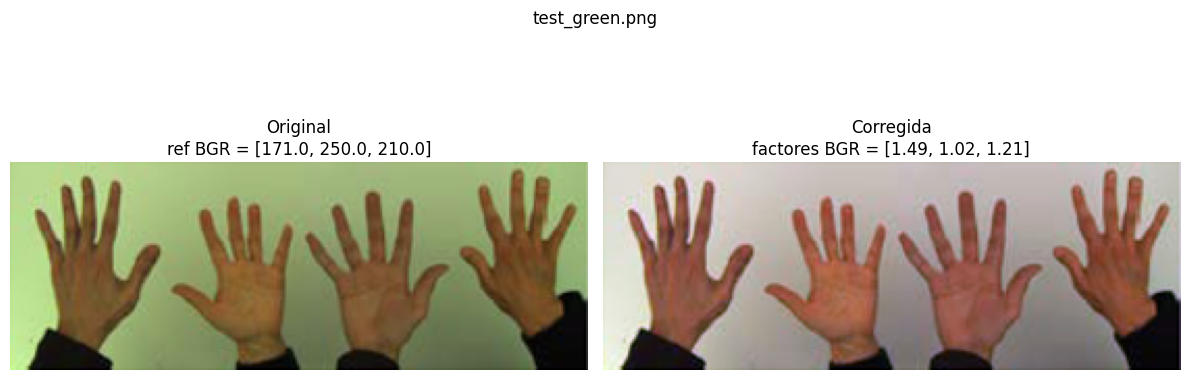

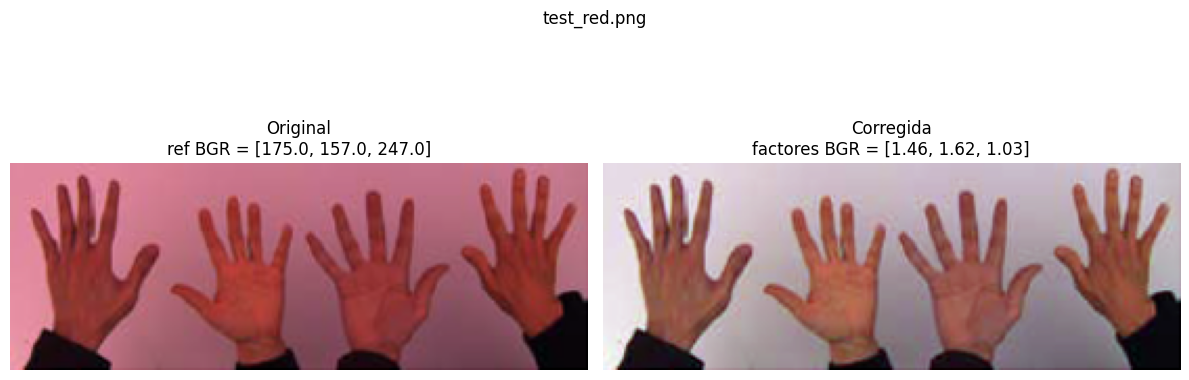

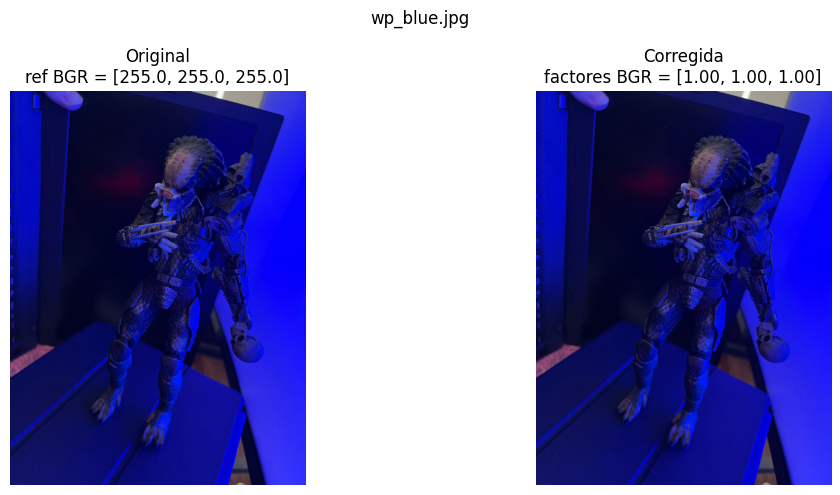

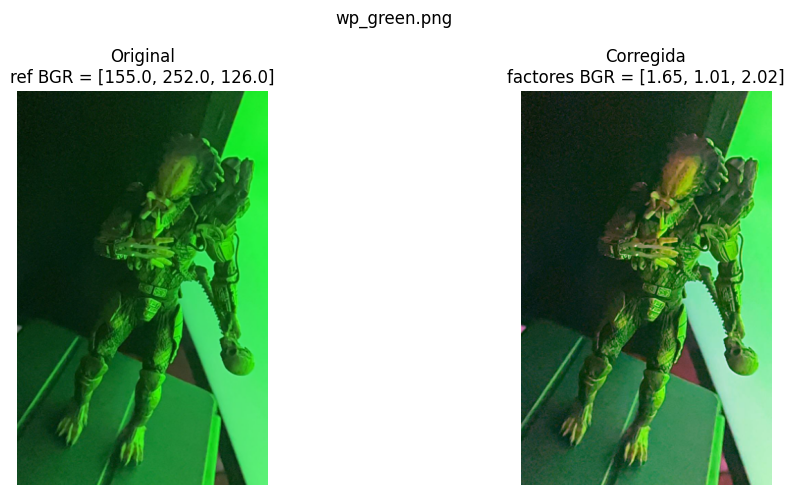

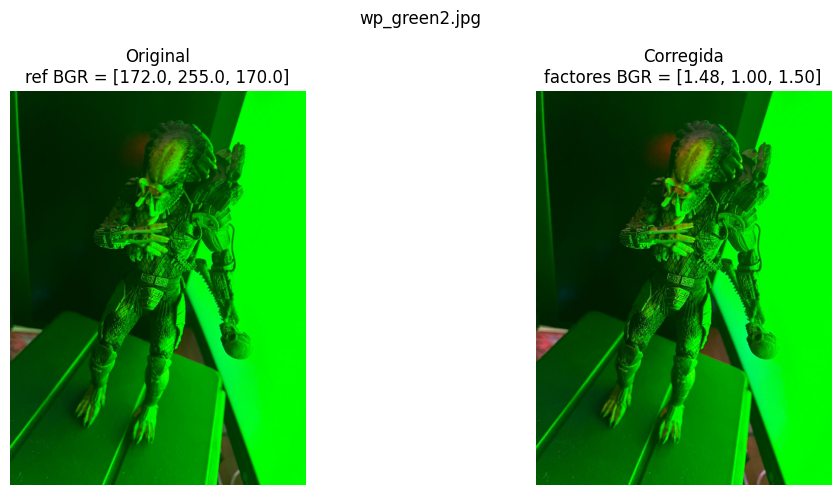

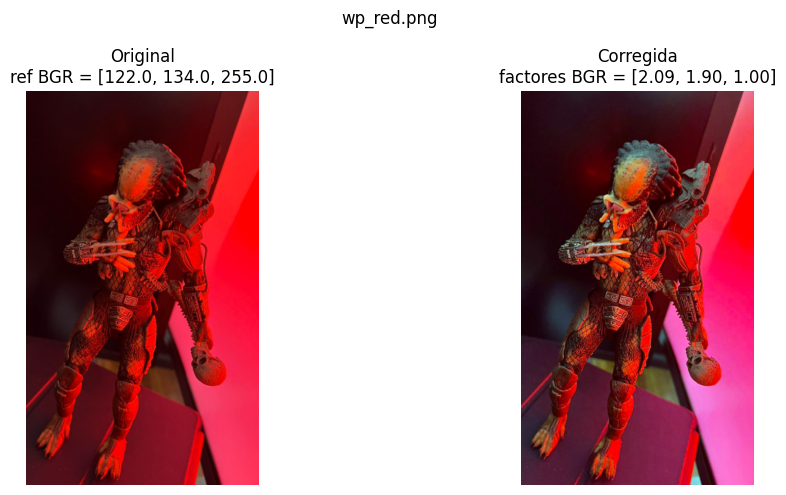

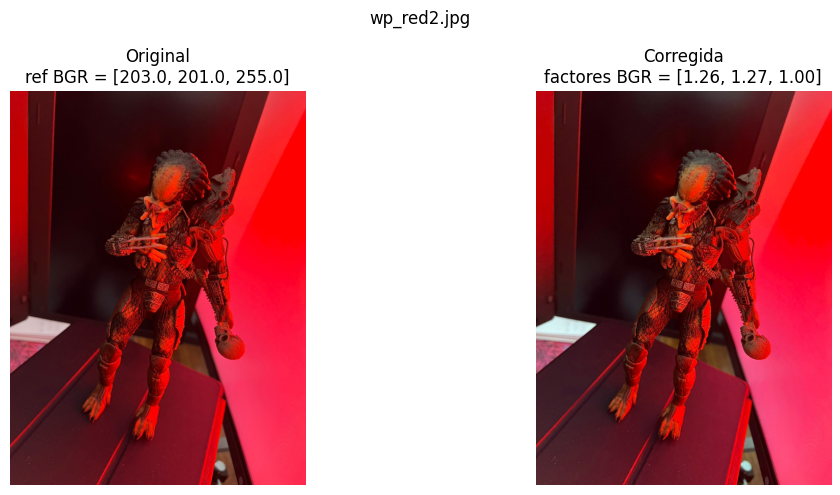

In [5]:
for image_path in image_paths:
    img = read_image_color(image_path)
    white_patch(img, percentile=100.0, title=image_path.name)

### Análisis de resultados y posibles fallas

Los resultados obtenidos muestran dos comportamientos bien distintos según el grupo de imágenes:

**1. Imágenes `test_*.png` (manos): la corrección funciona muy bien.**

- En las tres imágenes (dominante azul, verde y roja) el fondo — que en la escena real es blanco/gris — recupera un tono prácticamente neutro y la piel vuelve a un color natural.
- La clave está en los valores de referencia: por ejemplo en `test_blue.png` la referencia por canal fue BGR = [200, 138, 165], lejos de la saturación. Eso deja margen para factores de escala significativos ([1.27, 1.85, 1.55]) que efectivamente compensan la dominante.
- Se cumple el supuesto del algoritmo: existe una región realmente blanca (el fondo) que actúa como referencia confiable.

**2. Imágenes `wp_*` (figura con luz LED de color): la corrección falla o es insuficiente.**

- **`wp_blue.jpg` es el caso extremo:** la referencia dio BGR = [255, 255, 255], por lo que los factores resultaron [1.00, 1.00, 1.00] y la imagen corregida es **idéntica a la original**. Hay al menos un píxel saturado en cada canal (reflejos especulares y la propia fuente de luz), y con el máximo ya en 255 el método no tiene nada que escalar.
- En `wp_green.png`, `wp_green2.jpg`, `wp_red.png` y `wp_red2.jpg` el canal dominante está saturado o casi (250–255), así que su factor es ~1.0 y solo se amplifican los otros dos canales (por ejemplo [2.09, 1.90, 1.00] en `wp_red.png`). El resultado mejora zonas puntuales (se recuperan algunos grises en paredes y de la mesa) pero la dominante de color **persiste claramente**: la escena sigue viéndose verde o roja.
- La causa de fondo es que la iluminación LED es casi monocromática: los píxeles "más brillantes" no corresponden a un objeto blanco sino a la propia luz coloreada, violando el supuesto central de White Patch. Donde un canal casi no recibió energía (p. ej. el rojo bajo luz verde), no hay información que recuperar multiplicando: solo se amplifica ruido.

**Fallas del método confirmadas en los resultados:**
1. **Ausencia de parche blanco real:** en las `wp_*` la zona más brillante es la fuente de luz coloreada, no un blanco de referencia; la corrección queda sesgada.
2. **Saturación de canales:** píxeles ya en 255 anulan la corrección (caso `wp_blue.jpg`, factores = 1) o la limitan (resto de las `wp_*`).
3. **Sensibilidad a outliers:** basta un píxel saturado por reflejo especular para fijar el máximo del canal. Usar un percentil alto (p. ej. 99) en lugar del máximo mitiga esto.
4. **Balance global:** al aplicar un único factor por canal no se corrigen variaciones espaciales de la iluminación (las sombras de la escena mantienen el tinte).
5. **Pérdida de información:** si un canal fue capturado casi sin señal, multiplicarlo no restaura el color verdadero, solo amplifica ruido y errores de cuantización.

La celda siguiente compara el máximo clásico con el percentil 99: en `test_blue.png` los factores pasan de [1.28, 1.85, 1.55] a [1.42, 2.09, 1.67], logrando un blanco más limpio al ignorar los píxeles extremos.

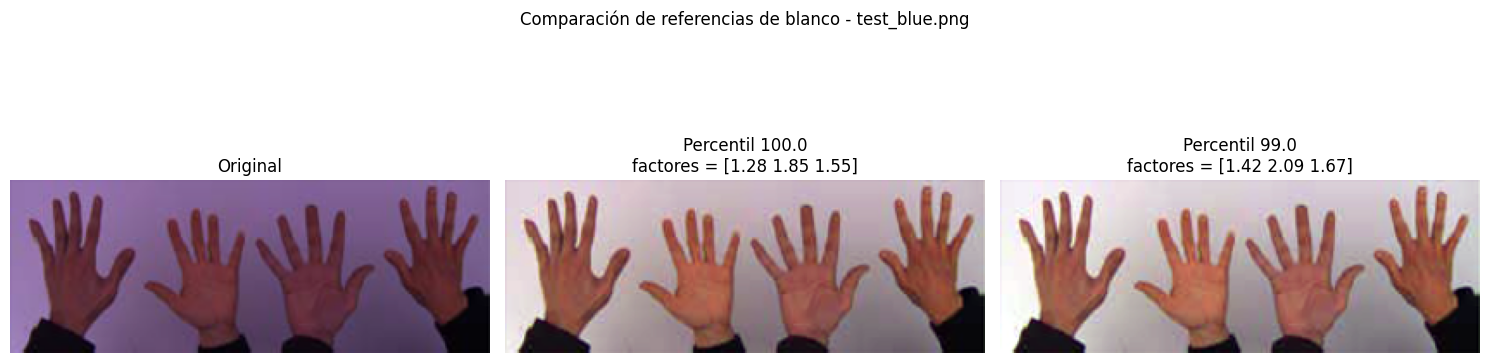

In [6]:
# Comparación máximo vs. percentil 99 en una imagen de ejemplo
example_path = image_paths[0]
example_img = read_image_color(example_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Comparación de referencias de blanco - {example_path.name}")

axes[0].imshow(bgr_to_rgb(example_img))
axes[0].set_title("Original")
axes[0].axis("off")

for ax, percentile in zip(axes[1:], [100.0, 99.0]):
    corrected, factors = white_patch(example_img, percentile=percentile, show=False)
    ax.imshow(bgr_to_rgb(corrected))
    ax.set_title(f"Percentil {percentile}\nfactores = {factors.round(2)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

---

## Parte 2 - Histogramas en escala de grises

Se leen `img1_tp.png` e `img2_tp.png` en escala de grises, se calculan sus histogramas y se comparan.

Para imágenes de 8 bits, lo natural es usar **256 bins** en el rango `[0, 256)`, ya que cada bin representa un nivel de gris entero (0-255). Este criterio es el mismo que se utiliza en el material de histogramas del curso (`Material/Codigo/Clase2/01.Brillo.ipynb`).

In [7]:
def read_image_gray(image_path):
    img = cv.imread(str(image_path), cv.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")
    return img


def compute_histogram(img, bins=256):
    hist, bin_edges = np.histogram(img.ravel(), bins=bins, range=(0, 256))
    return hist, bin_edges


IMG1_PATH = Path("img1_tp.png")
IMG2_PATH = Path("img2_tp.png")
N_BINS = 256

img1 = read_image_gray(IMG1_PATH)
img2 = read_image_gray(IMG2_PATH)

hist1, edges1 = compute_histogram(img1, N_BINS)
hist2, edges2 = compute_histogram(img2, N_BINS)

print(f"{IMG1_PATH}: shape={img1.shape}, min={img1.min()}, max={img1.max()}, media={img1.mean():.2f}")
print(f"{IMG2_PATH}: shape={img2.shape}, min={img2.min()}, max={img2.max()}, media={img2.mean():.2f}")
print(f"¿Histogramas idénticos? {np.array_equal(hist1, hist2)}")

img1_tp.png: shape=(288, 287), min=2, max=255, media=154.81
img2_tp.png: shape=(288, 287), min=2, max=255, media=154.81
¿Histogramas idénticos? True


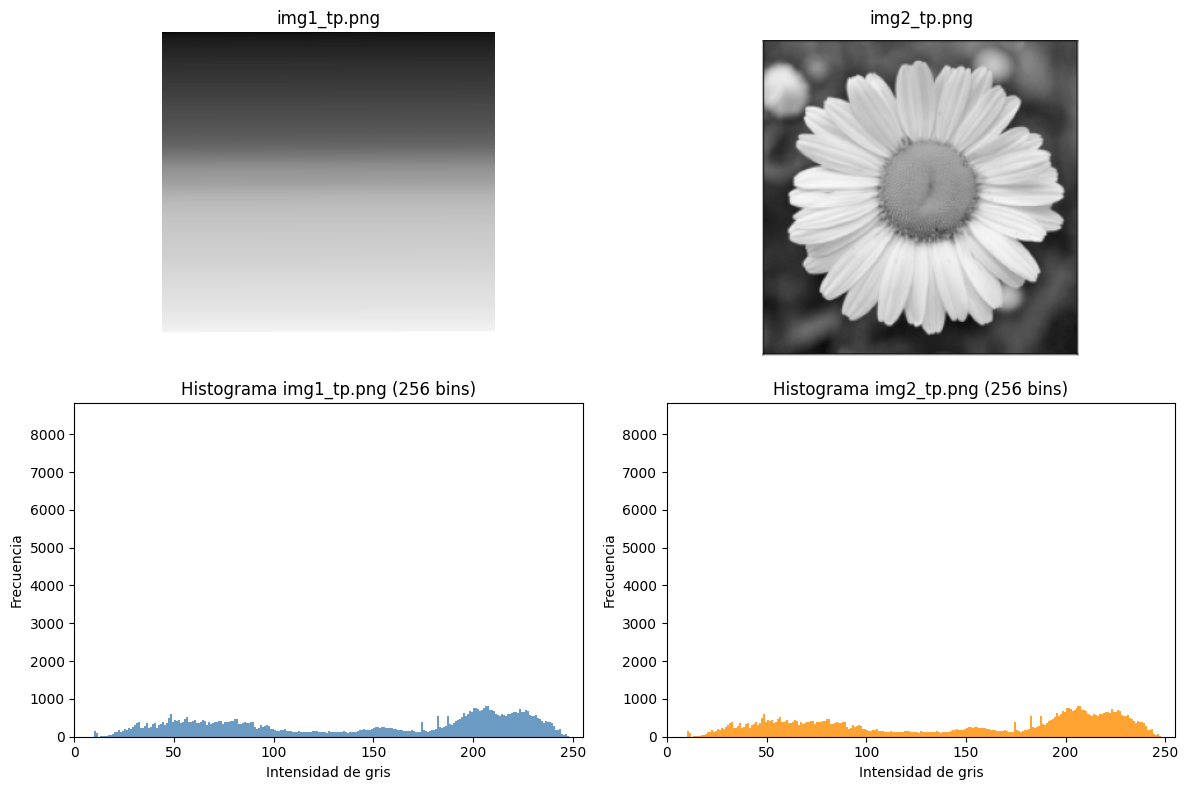

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title(IMG1_PATH.name)
axes[0, 0].axis("off")

axes[0, 1].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title(IMG2_PATH.name)
axes[0, 1].axis("off")

bin_centers = (edges1[:-1] + edges1[1:]) / 2

axes[1, 0].bar(bin_centers, hist1, width=1.0, color="steelblue", alpha=0.8)
axes[1, 0].set_title(f"Histograma {IMG1_PATH.name} ({N_BINS} bins)")
axes[1, 0].set_xlabel("Intensidad de gris")
axes[1, 0].set_ylabel("Frecuencia")
axes[1, 0].set_xlim(0, 255)

axes[1, 1].bar(bin_centers, hist2, width=1.0, color="darkorange", alpha=0.8)
axes[1, 1].set_title(f"Histograma {IMG2_PATH.name} ({N_BINS} bins)")
axes[1, 1].set_xlabel("Intensidad de gris")
axes[1, 1].set_ylabel("Frecuencia")
axes[1, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

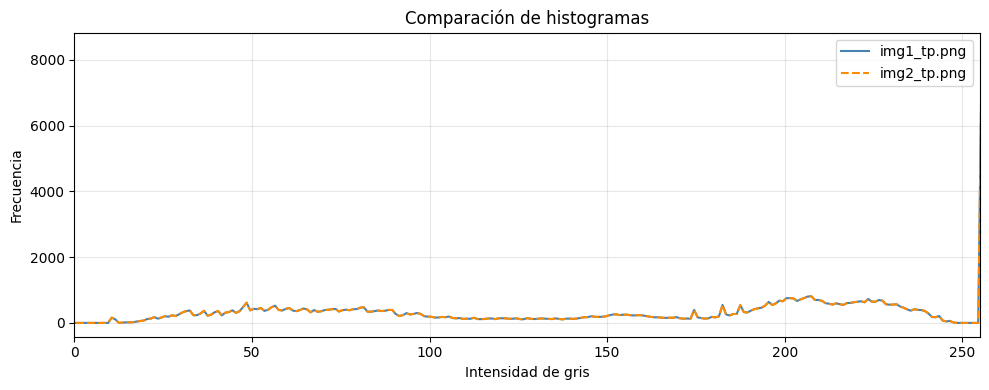

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(bin_centers, hist1, label=IMG1_PATH.name, color="steelblue", linewidth=1.5)
ax.plot(bin_centers, hist2, label=IMG2_PATH.name, color="darkorange", linewidth=1.5, linestyle="--")
ax.set_title("Comparación de histogramas")
ax.set_xlabel("Intensidad de gris")
ax.set_ylabel("Frecuencia")
ax.set_xlim(0, 255)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observaciones

Las dos imágenes no podrían ser más distintas en contenido: **`img1_tp.png` es un degradado vertical** (oscuro arriba, claro abajo) e **`img2_tp.png` es la fotografía de una margarita** sobre fondo desenfocado. Sin embargo, comparten forma (288×287), mínimo (2), máximo (255) y media (154.81), y la verificación numérica confirmó que sus **histogramas son exactamente idénticos** (`np.array_equal → True`); en el gráfico comparativo ambas curvas se superponen por completo.

Esto ocurre porque el histograma es una **estadística de primer orden**: cuenta cuántos píxeles hay en cada nivel de gris, pero **descarta por completo la información espacial** (dónde está cada intensidad en la imagen). Es muy probable que `img1_tp.png` haya sido construida a partir de `img2_tp.png` reordenando sus píxeles de oscuro a claro: el multiconjunto de intensidades es el mismo, solo cambia su ubicación.

En el histograma compartido se observa:
- dos zonas de concentración: una en tonos oscuros-medios (~30–90, el fondo de la flor / parte superior del degradado) y otra mayor en tonos claros (~190–240, los pétalos / parte inferior del degradado);
- un pico aislado en 255 (píxeles totalmente blancos);
- casi ausencia de negro puro (el mínimo es 2, no 0).

### ¿Sirven los histogramas como *features* para clasificación/detección?

**Como descriptor único, no son suficientes** para un modelo de clasificación o detección de imágenes en general. El ejemplo anterior es una demostración contundente: un degradado sintético y la foto de una flor — clases que cualquier modelo debería separar trivialmente — resultan **indistinguibles** para un clasificador que solo mire el histograma, porque comparten exactamente el mismo vector de características.

No obstante, los histogramas **sí pueden ser útiles** en contextos más acotados:
- **Preprocesamiento:** ecualización o normalización de contraste (ver `Material/Codigo/Clase2/02.Ecualizacion_histograma.ipynb`).
- **Característica complementaria:** combinados con descriptores espaciales (HOG, SIFT, CNN, etc.) aportan información global de iluminación y contraste.
- **Tareas específicas:** comparación de color/tonalidad en segmentación por retroproyección de histograma (ver material de Mean Shift en Clase 6).
- **Detección de anomalías simples:** cambios bruscos de iluminación entre frames consecutivos.

En resumen: el histograma resume la **distribución de intensidades**, pero no el **contenido estructural** de la imagen. Para entrenar un modelo robusto de clasificación o detección conviene usar *features* que capturen forma, textura y contexto espacial, reservando el histograma como información auxiliar o para etapas de preprocesamiento.